# Optimization Space: How Training Selects a Hypothesis

## 0. Introduction: Training Is a Selection Procedure

The previous notebooks separated evidence and possibility. The data space asks what the observed dataset can support. The hypothesis space asks what functions the model class makes available. This notebook isolates the third ingredient: the training procedure that selects one reported solution.

The workshop frame is:

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s.
$$

Here $\mathcal{H}$ is the hypothesis space, $\mathcal{D}$ is the observed dataset, $\mathcal{O}$ is the optimisation and selection procedure, and $s$ is the selected solution.

This notebook follows the chain:

$$
\text{candidate functions}
\rightarrow
\text{objective}
\rightarrow
\text{training path}
\rightarrow
\text{selected solution}.
$$

The central question is:

$$
\text{Given }\mathcal{D}\text{ and }\mathcal{H},\text{ how does training select one solution }s?
$$

### Running model

Most examples use the two-parameter linear model

$$
h_{\theta}(x)=\theta_0+\theta_1x,
\qquad
\theta=(\theta_0,\theta_1).
$$

This model is deliberately simple. It lets us show both the fitted function in data space and the objective landscape in parameter space. Later sections use toy quadratic or non-convex objectives only when that geometry is the point.

### Optimisation audit

| Question | What it asks |
|---|---|
| What is being selected? | Which member of $\mathcal{H}$ becomes $s$? |
| What defines success? | Which loss, risk, and penalty define the objective? |
| What landscape is searched? | How do scaling, curvature, and parameterisation shape the search? |
| What path is followed? | How do learning rate, stochasticity, and initialisation affect iterates? |
| Which iterate is reported? | How do stopping and validation rules select $s$? |


## Setup

The setup cell imports libraries and shared helpers. It should not choose the important settings for the examples. Each demo cell defines its own editable variables at the top.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src" / "nextgen2026_mlai_workshops").exists()),
    Path.cwd(),
)
src_dir = PROJECT_ROOT / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

for module_name in list(sys.modules):
    if module_name.startswith("nextgen2026_mlai_workshops"):
        del sys.modules[module_name]

from nextgen2026_mlai_workshops.optimization_space import (
    COLORS,
    LINE_GRID,
    RESIDUAL_GRID,
    VIRIDIS_CMAP,
    absolute_loss,
    configure_optimization_matplotlib,
    describe_lambda,
    display_markdown,
    display_table,
    evaluate_objective_mesh,
    fit_linear_absolute_grid,
    gradient_descent,
    huber_loss,
    linear_design,
    linear_predictions,
    make_linear_dataset,
    make_loss_mesh,
    markdown_table,
    mse_gradient,
    mse_objective,
    nonconvex_gradient,
    nonconvex_objective,
    plot_3d_landscape,
    plot_linear_fit,
    plot_observed,
    quadratic_path,
    ridge_solution,
    set_seed,
    true_linear_function,
)


def format_theta(theta):
    theta = np.asarray(theta, dtype=float)
    return f"({theta[0]:.3f}, {theta[1]:.3f})"


def loss_values(residual, loss_name="squared", huber_delta=1.0):
    residual = np.asarray(residual, dtype=float)
    if loss_name == "squared":
        return residual**2
    if loss_name == "absolute":
        return np.abs(residual)
    if loss_name == "huber":
        return huber_loss(residual, delta=huber_delta)
    raise ValueError("loss_name must be 'squared', 'absolute', or 'huber'")


def linear_empirical_loss(X, y, theta, loss_name="squared", huber_delta=1.0):
    residual = X @ np.asarray(theta, dtype=float) - y
    return float(np.mean(loss_values(residual, loss_name=loss_name, huber_delta=huber_delta)))


def linear_objective(X, y, theta, loss_name="squared", lambda_ridge=0.0, huber_delta=1.0):
    theta = np.asarray(theta, dtype=float)
    risk = linear_empirical_loss(X, y, theta, loss_name=loss_name, huber_delta=huber_delta)
    penalty = float(lambda_ridge * np.sum(theta**2))
    return risk + penalty


def objective_grid_for_loss(
    x,
    y,
    theta0_range,
    theta1_range,
    loss_name="squared",
    lambda_ridge=0.0,
    huber_delta=1.0,
    grid_size=120,
):
    T0, T1 = make_loss_mesh(theta0_range, theta1_range, points=grid_size)
    residual = T0[..., None] + T1[..., None] * np.asarray(x)[None, None, :] - np.asarray(y)[None, None, :]
    Z = np.mean(loss_values(residual, loss_name=loss_name, huber_delta=huber_delta), axis=2)
    if lambda_ridge:
        Z = Z + lambda_ridge * (T0**2 + T1**2)
    return T0, T1, Z


def fit_linear_loss(
    x,
    y,
    loss_name="squared",
    lambda_ridge=0.0,
    huber_delta=1.0,
    theta0_range=(-2.5, 2.5),
    theta1_range=(-1.0, 2.0),
    grid_size=281,
):
    X = linear_design(x)
    if loss_name == "squared":
        theta = ridge_solution(X, y, lam=lambda_ridge)
        return theta, linear_empirical_loss(X, y, theta, loss_name, huber_delta), linear_objective(X, y, theta, loss_name, lambda_ridge, huber_delta)

    T0, T1, Z = objective_grid_for_loss(
        x,
        y,
        theta0_range,
        theta1_range,
        loss_name=loss_name,
        lambda_ridge=lambda_ridge,
        huber_delta=huber_delta,
        grid_size=grid_size,
    )
    idx = np.unravel_index(int(np.argmin(Z)), Z.shape)
    theta = np.array([T0[idx], T1[idx]])
    return theta, linear_empirical_loss(X, y, theta, loss_name, huber_delta), float(Z[idx])


def plot_2d_landscape(
    ax,
    T0,
    T1,
    Z,
    title,
    levels=None,
    path=None,
    selected=None,
    path_label="optimisation path",
    selected_label=r"$\theta_T$",
    path_color=None,
    selected_color=None,
    alpha=1.0,
    legend_fontsize=8,
):
    if levels is None:
        levels = np.linspace(float(np.min(Z)), float(np.quantile(Z, 0.92)), 22)
    ax.contourf(T0, T1, Z, levels=levels, cmap=VIRIDIS_CMAP, alpha=alpha)
    ax.contour(T0, T1, Z, levels=levels, colors="white", alpha=0.35, linewidths=0.6)
    if path is not None:
        path = np.asarray(path)
        ax.plot(
            path[:, 0],
            path[:, 1],
            marker="o",
            ms=3.0,
            lw=1.6,
            color=path_color or COLORS["selected"],
            label=path_label,
        )
    if selected is not None:
        selected = np.asarray(selected)
        ax.scatter(
            selected[0],
            selected[1],
            color=selected_color or COLORS["selected"],
            s=55,
            label=selected_label,
            zorder=5,
        )
    ax.set_title(title)
    ax.set_xlabel(r"$\theta_0$")
    ax.set_ylabel(r"$\theta_1$")
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(fontsize=legend_fontsize)
    return levels


def plot_fit_with_residuals(ax, x, y, theta, title, label="selected fit", color=None, x_grid=None):
    if x_grid is None:
        x_grid = LINE_GRID
    theta = np.asarray(theta, dtype=float)
    y_hat = linear_design(x) @ theta
    plot_observed(ax, x, y, label="observed data")
    for xi, yi, pred in zip(x, y, y_hat):
        ax.plot([xi, xi], [yi, pred], color=color or COLORS["selected"], alpha=0.35, lw=1.1)
    plot_linear_fit(ax, theta, x_grid=x_grid, label=label, color=color or COLORS["selected"])
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)


def minibatch_training_path(X, y, theta0, learning_rate, num_updates, batch_size, seed=7, shuffle_each_epoch=True, lam=0.0):
    rng = set_seed(seed)
    theta = np.asarray(theta0, dtype=float).copy()
    path = [theta.copy()]
    values = [mse_objective(X, y, theta, lam=lam)]
    n = len(y)
    batch_size = int(max(1, min(batch_size, n)))
    order = rng.permutation(n)
    cursor = 0
    for _ in range(num_updates):
        if shuffle_each_epoch:
            if cursor + batch_size > n:
                order = rng.permutation(n)
                cursor = 0
            idx = order[cursor : cursor + batch_size]
            cursor += batch_size
        else:
            idx = rng.choice(n, size=batch_size, replace=False)
        theta = theta - learning_rate * mse_gradient(X[idx], y[idx], theta, lam=lam)
        path.append(theta.copy())
        values.append(mse_objective(X, y, theta, lam=lam))
    return np.asarray(path), np.asarray(values)


def finite_path_inside(path, theta0_range, theta1_range):
    path = np.asarray(path, dtype=float)
    mask = np.isfinite(path).all(axis=1)
    mask &= (path[:, 0] >= theta0_range[0]) & (path[:, 0] <= theta0_range[1])
    mask &= (path[:, 1] >= theta1_range[0]) & (path[:, 1] <= theta1_range[1])
    return path[mask]


configure_optimization_matplotlib()

print("Setup complete. Optimisation helpers imported.")


Setup complete. Optimisation helpers imported.


## 1. What Is Being Selected?

### Motivation

A hypothesis space contains many candidate functions. Training selects one of them. Before introducing gradients or landscapes, look at the basic selection problem directly:

$$
\text{Which candidate function becomes the reported solution?}
$$

### Exploration

The observed data and hypothesis space are fixed. The learner edits candidate parameters and highlights one active candidate.


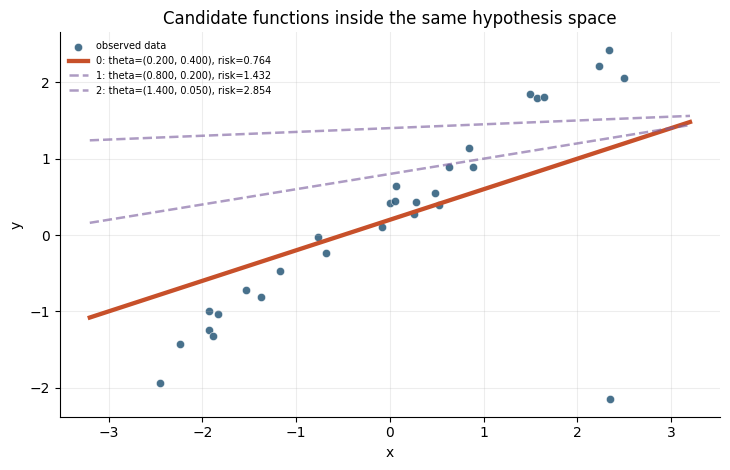

Active theta = [0.2 0.4]
Empirical risk = 0.764
Changed ingredient: selected candidate inside fixed H


In [2]:
seed = 11
outlier = True
candidate_thetas = [
    (0.2, 0.4),
    (0.8, 0.2),
    (1.4, 0.05),
]
active_candidate = 0

x, y = make_linear_dataset(seed=seed, outlier=outlier)
X = linear_design(x)
candidate_thetas = [np.asarray(theta, dtype=float) for theta in candidate_thetas]
active_candidate = int(np.clip(active_candidate, 0, len(candidate_thetas) - 1))
risks = [mse_objective(X, y, theta) for theta in candidate_thetas]
theta = candidate_thetas[active_candidate]
risk = risks[active_candidate]

fig, ax = plt.subplots(figsize=(7.4, 4.8))
plot_observed(ax, x, y)
for i, candidate in enumerate(candidate_thetas):
    active = i == active_candidate
    color = COLORS["selected"] if active else COLORS["alt"]
    lw = 3.1 if active else 1.8
    alpha = 1.0 if active else 0.62
    plot_linear_fit(
        ax,
        candidate,
        label=f"{i}: theta={format_theta(candidate)}, risk={risks[i]:.3f}",
        color=color,
        lw=lw,
        ls="-" if active else "--",
    )
    ax.lines[-1].set_alpha(alpha)
ax.set_title("Candidate functions inside the same hypothesis space")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

print(f"Active theta = {theta}")
print(f"Empirical risk = {risk:.3f}")
print("Changed ingredient: selected candidate inside fixed H")


### Plot interpretation

The plotted candidates are all available inside the same $\mathcal{H}$. The data do not automatically name one of them. A selection rule is needed.

The plot should not be read as:

$$
\mathcal{D}\text{ alone selects the trained model.}
$$

It should be read as:

$$
\mathcal{D}\text{ provides evidence, while }\mathcal{O}\text{ selects among candidates.}
$$

### Mathematical unpacking

The observed dataset is

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}.
$$

A selected solution has the form

$$
s=h_{\widehat{\theta}}.
$$

At this point, $\widehat{\theta}$ is just the parameter value selected by some rule. The next sections define that rule.

### Researcher takeaway

The first optimisation question is not "did the model fit?" It is:

$$
\text{Which member of }\mathcal{H}\text{ did training select, and why?}
$$


## 2. What Defines a Mistake?

### Motivation

The loss function defines what training treats as an error. Changing the loss can change the selected solution, even when the dataset and hypothesis space are fixed.

This section asks:

$$
\text{What does the optimiser count as a mistake?}
$$

### Exploration

Use the same dataset and linear hypothesis space. Compare squared loss, absolute loss, and Huber loss. Toggle the outlier and switch the selected loss.


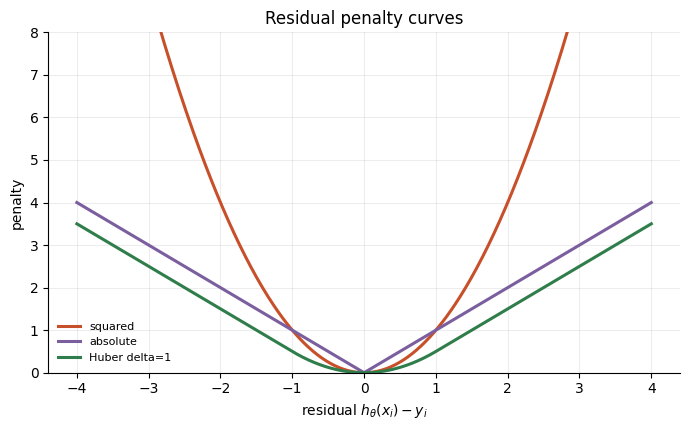

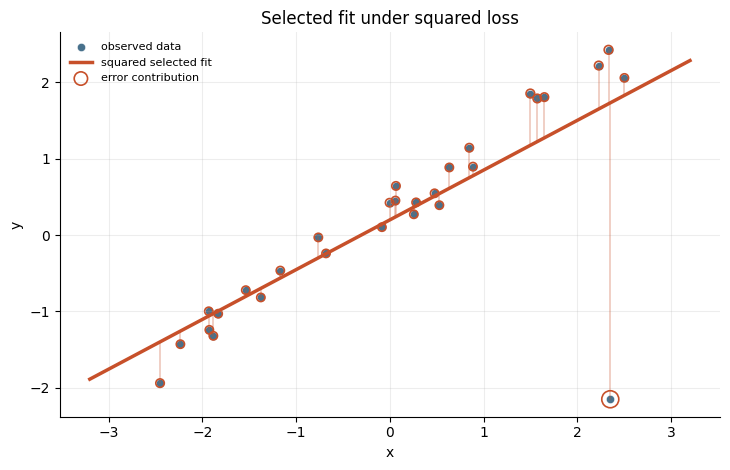

Loss = squared
Selected theta = [0.1987917  0.65188837]
Total empirical loss = 0.624
Changed ingredient: O, via the loss


In [3]:
seed = 11
outlier = True
loss_name = "squared"  # "squared", "absolute", "huber"
huber_delta = 1.0

x, y = make_linear_dataset(seed=seed, outlier=outlier)
X = linear_design(x)
theta_hat, empirical_loss, _ = fit_linear_loss(x, y, loss_name=loss_name, huber_delta=huber_delta)
residual = X @ theta_hat - y
contributions = loss_values(residual, loss_name=loss_name, huber_delta=huber_delta)

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(RESIDUAL_GRID, loss_values(RESIDUAL_GRID, "squared"), color=COLORS["selected"], lw=2.2, label="squared")
ax.plot(RESIDUAL_GRID, loss_values(RESIDUAL_GRID, "absolute"), color=COLORS["alt"], lw=2.2, label="absolute")
ax.plot(RESIDUAL_GRID, loss_values(RESIDUAL_GRID, "huber", huber_delta), color=COLORS["regularised"], lw=2.2, label=f"Huber delta={huber_delta:g}")
ax.set_ylim(0, 8)
ax.set_title("Residual penalty curves")
ax.set_xlabel(r"residual $h_\theta(x_i)-y_i$")
ax.set_ylabel("penalty")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.4, 4.8))
plot_fit_with_residuals(ax, x, y, theta_hat, f"Selected fit under {loss_name} loss", label=f"{loss_name} selected fit")
if np.max(contributions) > 0:
    sizes = 35 + 115 * contributions / np.max(contributions)
else:
    sizes = np.full_like(contributions, 35.0)
ax.scatter(x, y, s=sizes, facecolor="none", edgecolor=COLORS["selected"], linewidth=1.2, label="error contribution")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Loss = {loss_name}")
print(f"Selected theta = {theta_hat}")
print(f"Total empirical loss = {empirical_loss:.3f}")
print("Changed ingredient: O, via the loss")


### Plot interpretation

Squared loss gives large residuals disproportionate influence. Absolute loss is less dominated by large residuals. Huber loss behaves quadratically near zero and more linearly for large residuals.

So the plot should not be read as:

$$
\text{different losses are just different numerical choices.}
$$

It should be read as:

$$
\text{the loss changes the definition of success.}
$$

### Mathematical unpacking

A loss function maps prediction and target to a penalty:

$$
\ell(\widehat{y},y)\geq 0.
$$

Using the residual $r=\widehat{y}-y$, squared and absolute loss are:

$$
\ell_2(r)=r^2,
\qquad
\ell_1(r)=|r|.
$$

Huber loss is:

$$
\ell_{\delta}(r)=
\begin{cases}
\frac{1}{2}r^2, & |r|\leq \delta,\\
\delta(|r|-\frac{1}{2}\delta), & |r|>\delta.
\end{cases}
$$

The empirical risk is:

$$
\widehat{R}_{\mathcal{D}}(h_{\theta})
=
\frac{1}{n}\sum_{i=1}^{n}\ell(h_{\theta}(x_i),y_i).
$$

For squared-error prediction, the population target is a conditional mean. For absolute-error prediction, the population target is a conditional median. This means changing the loss can also change the estimand.

### Researcher takeaway

The loss is part of $\mathcal{O}$. It defines the operational meaning of a good fit.

The practical question is:

$$
\text{Does this loss match the research claim?}
$$


## 3. What Objective Is Being Minimized?

### Motivation

A loss penalises one prediction. An objective combines losses over the dataset and may add penalties. This objective is the scalar surface training tries to reduce.

This section asks:

$$
\text{What scalar quantity is training trying to make small?}
$$

### Exploration

Use the same dataset and linear model. Manually change $\theta_0$ and $\theta_1$ and watch the fitted line and objective value update.


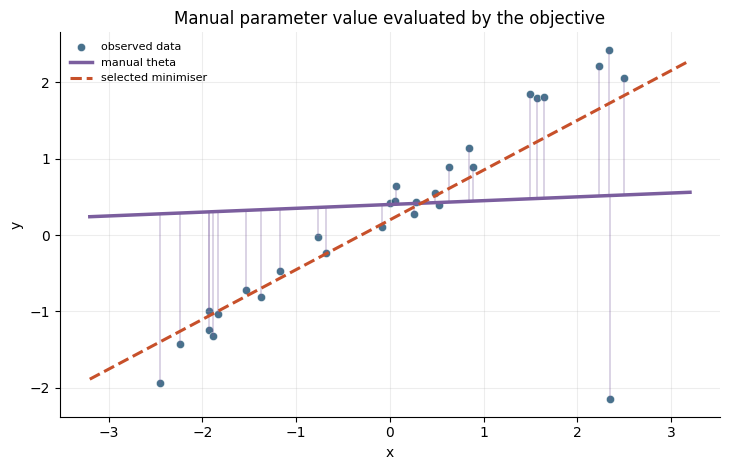

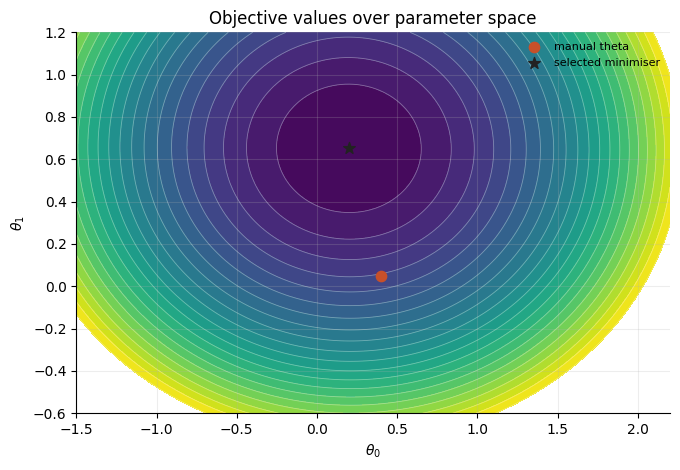

Manual theta = (0.400, 0.050)
Empirical risk = 1.463
Penalty = 0.000
Objective J(theta) = 1.463


In [4]:
seed = 11
outlier = True
theta0_manual = 0.4
theta1_manual = 0.05
loss_name = "squared"
lambda_ridge = 0.0
huber_delta = 1.0

x, y = make_linear_dataset(seed=seed, outlier=outlier)
X = linear_design(x)
theta_manual = np.array([theta0_manual, theta1_manual], dtype=float)
theta_hat, _, _ = fit_linear_loss(x, y, loss_name=loss_name, lambda_ridge=lambda_ridge, huber_delta=huber_delta)
risk = linear_empirical_loss(X, y, theta_manual, loss_name=loss_name, huber_delta=huber_delta)
penalty = float(lambda_ridge * np.sum(theta_manual**2))
objective = risk + penalty

fig, ax = plt.subplots(figsize=(7.4, 4.8))
plot_fit_with_residuals(ax, x, y, theta_manual, "Manual parameter value evaluated by the objective", label="manual theta", color=COLORS["alt"])
plot_linear_fit(ax, theta_hat, label="selected minimiser", color=COLORS["selected"], lw=2.2, ls="--")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

T0, T1, Z = objective_grid_for_loss(
    x,
    y,
    (-1.5, 2.2),
    (-0.6, 1.2),
    loss_name=loss_name,
    lambda_ridge=lambda_ridge,
    huber_delta=huber_delta,
    grid_size=140,
)
fig, ax = plt.subplots(figsize=(6.9, 4.8))
levels = plot_2d_landscape(ax, T0, T1, Z, "Objective values over parameter space", selected=theta_manual, selected_label="manual theta")
ax.scatter(theta_hat[0], theta_hat[1], color=COLORS["truth"], marker="*", s=75, label="selected minimiser")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Manual theta = ({theta0_manual:.3f}, {theta1_manual:.3f})")
print(f"Empirical risk = {risk:.3f}")
print(f"Penalty = {penalty:.3f}")
print(f"Objective J(theta) = {objective:.3f}")


### Plot interpretation

A parameter value is not good or bad by itself. It is evaluated by the objective. The same line can look plausible visually while scoring poorly if the loss or penalty makes it costly.

### Mathematical unpacking

A common empirical objective is:

$$
J(\theta)
=
\widehat{R}_{\mathcal{D}}(h_{\theta})+\lambda\Omega(\theta).
$$

Here $\widehat{R}_{\mathcal{D}}$ measures fit to the observed data, $\Omega$ is a penalty or preference, and $\lambda$ controls its strength.

The selected parameter is often written:

$$
\widehat{\theta}
\in
\operatorname*{arg\,min}_{\theta\in\Theta}J(\theta).
$$

In practice, training usually returns an approximate finite-time solution:

$$
\theta_0,\theta_1,\ldots,\theta_T,
\qquad
s=h_{\theta_T}.
$$

### Researcher takeaway

The objective is the formal selection criterion. Before interpreting a trained model, ask:

$$
\text{What objective selected this solution?}
$$


## 4. What Landscape Does the Optimiser See?

### Motivation

Optimisers move through parameter space, not directly through the plotted function space. Feature scaling and parameterisation can change the shape of the objective landscape.

This section asks:

$$
\text{What geometry does training search through?}
$$

### Exploration

Fit the same linear relationship with unscaled $x$ or scaled $x$. Compare the data-space fit with the objective landscape in $(\theta_0,\theta_1)$.


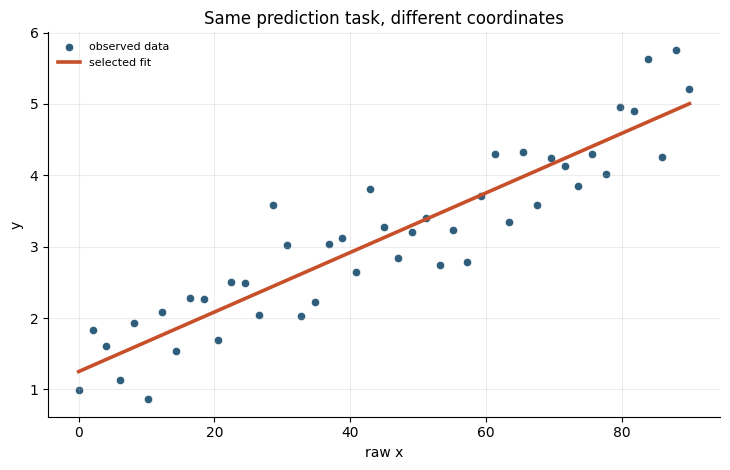

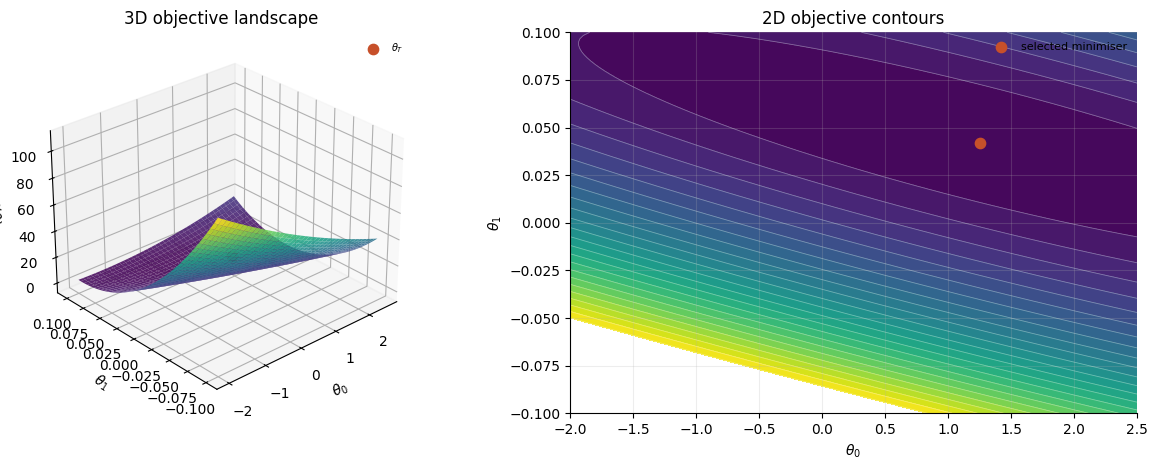

Feature scaled = False
Condition number of X^T X = 10572.29
Changed ingredient: O's coordinate geometry


In [5]:
seed = 19
scale_feature = False
theta0_range = (-2.0, 2.5)
theta1_range = (-0.1, 0.1)
grid_size = 120
manual_theta = None

rng = set_seed(seed)
x_raw = np.linspace(0, 90, 45)
y = 1.2 + 0.045 * x_raw + rng.normal(0, 0.55, len(x_raw))
if scale_feature:
    x_model = (x_raw - x_raw.mean()) / x_raw.std()
    if theta1_range == (-0.1, 0.1):
        theta1_plot_range = (-1.5, 1.8)
    else:
        theta1_plot_range = theta1_range
else:
    x_model = x_raw
    theta1_plot_range = theta1_range
X = linear_design(x_model)
theta_hat = ridge_solution(X, y, lam=0.0)
condition_number = np.linalg.cond(X.T @ X)

x_grid_raw = np.linspace(x_raw.min(), x_raw.max(), 300)
x_grid_model = (x_grid_raw - x_raw.mean()) / x_raw.std() if scale_feature else x_grid_raw
y_grid_hat = linear_design(x_grid_model) @ theta_hat

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.scatter(x_raw, y, s=35, color=COLORS["data"], edgecolor="white", linewidth=0.4, label="observed data")
ax.plot(x_grid_raw, y_grid_hat, color=COLORS["selected"], lw=2.6, label="selected fit")
ax.set_title("Same prediction task, different coordinates")
ax.set_xlabel("raw x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

T0, T1, Z = objective_grid_for_loss(x_model, y, theta0_range, theta1_plot_range, grid_size=grid_size)
objective_fn = lambda theta: mse_objective(X, y, theta)
fig = plt.figure(figsize=(12.4, 4.8))
ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
ax_contour = fig.add_subplot(1, 2, 2)
plot_3d_landscape(ax_surface, T0, T1, Z, "3D objective landscape", objective_fn=objective_fn, selected=theta_hat)
levels = np.linspace(float(np.min(Z)), float(np.quantile(Z, 0.92)), 24)
plot_2d_landscape(ax_contour, T0, T1, Z, "2D objective contours", levels=levels, selected=theta_hat, selected_label="selected minimiser")
if manual_theta is not None:
    manual_theta = np.asarray(manual_theta, dtype=float)
    ax_contour.scatter(manual_theta[0], manual_theta[1], color=COLORS["alt"], s=55, label="manual theta")
    ax_contour.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Feature scaled = {scale_feature}")
print(f"Condition number of X^T X = {condition_number:.2f}")
print("Changed ingredient: O's coordinate geometry")


### Plot interpretation

The prediction problem can be essentially the same while the optimiser sees a different landscape. Unscaled features often create stretched contours. Scaled features often produce a more balanced landscape.

So the plot should not be read as:

$$
\text{scaling is only cosmetic.}
$$

It should be read as:

$$
\text{scaling changes the geometry of finite optimisation.}
$$

### Mathematical unpacking

For the linear model with squared loss:

$$
h_{\theta}(x)=\theta_0+\theta_1x,
$$

$$
J(\theta_0,\theta_1)
=
\frac{1}{n}\sum_{i=1}^{n}(\theta_0+\theta_1x_i-y_i)^2.
$$

In matrix form:

$$
J(\theta)=\frac{1}{n}\|X\theta-y\|_2^2.
$$

The gradient and Hessian are:

$$
\nabla J(\theta)=\frac{2}{n}X^{\top}(X\theta-y),
$$

$$
\nabla^2J(\theta)=\frac{2}{n}X^{\top}X.
$$

Rescaling features changes $X^{\top}X$, so it changes the curvature of the landscape seen by the optimiser.

### Researcher takeaway

The landscape is not just a picture. It is the object the optimiser searches.

The practical question is:

$$
\text{What parameter geometry did training actually use?}
$$


## 5. How Does Gradient Descent Move?

### Motivation

Gradient descent is a sequence of updates, not a direct jump to the optimum. The selected model depends on the path and on the finite update budget.

This section asks:

$$
\text{What path does training follow?}
$$

### Exploration

Use the same two-parameter linear objective. Hold dataset, objective, initialisation, and number of updates fixed. Change only the learning rate.


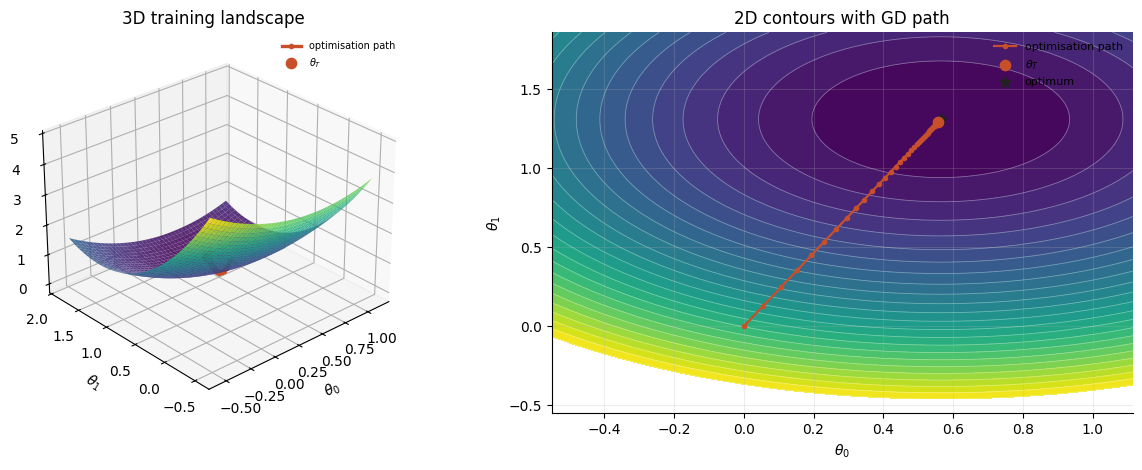

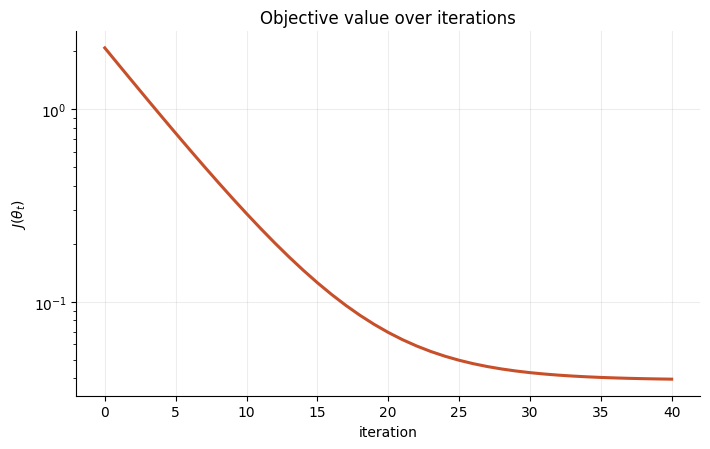

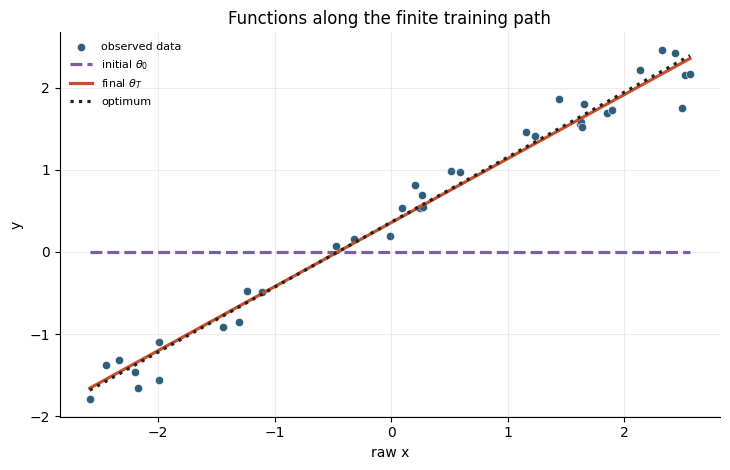

Learning rate = 0.05
Number of steps = 40
Final theta_T = [0.55596242 1.29117805]
Final objective = 0.040
Changed ingredient: O, via update size


In [6]:
seed = 13
learning_rate = 0.05
num_steps = 40
theta_init = np.array([0.0, 0.0])
scale_feature = True

x_raw, y = make_linear_dataset(n=36, seed=seed, outlier=False)
x_model = (x_raw - x_raw.mean()) / x_raw.std() if scale_feature else x_raw
X = linear_design(x_model)
theta_star = ridge_solution(X, y)
objective_fn = lambda theta: mse_objective(X, y, theta)
grad_fn = lambda theta: mse_gradient(X, y, theta)
theta_path, objective_values = gradient_descent(theta_init, grad_fn, objective_fn, learning_rate, num_steps)

finite_path = theta_path[np.isfinite(theta_path).all(axis=1)]
theta0_range = (min(finite_path[:, 0].min(), theta_star[0]) - 0.55, max(finite_path[:, 0].max(), theta_star[0]) + 0.55)
theta1_range = (min(finite_path[:, 1].min(), theta_star[1]) - 0.55, max(finite_path[:, 1].max(), theta_star[1]) + 0.55)
T0, T1 = make_loss_mesh(theta0_range, theta1_range, points=130)
Z = evaluate_objective_mesh(T0, T1, objective_fn)
visible_path = finite_path_inside(theta_path, theta0_range, theta1_range)

fig = plt.figure(figsize=(12.4, 4.8))
ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
ax_contour = fig.add_subplot(1, 2, 2)
plot_3d_landscape(ax_surface, T0, T1, Z, "3D training landscape", path=visible_path, objective_fn=objective_fn, selected=theta_path[-1])
levels = np.linspace(float(np.min(Z)), float(np.quantile(Z, 0.92)), 24)
plot_2d_landscape(ax_contour, T0, T1, Z, "2D contours with GD path", levels=levels, path=visible_path, selected=theta_path[-1])
ax_contour.scatter(theta_star[0], theta_star[1], color=COLORS["truth"], s=75, marker="*", label="optimum")
ax_contour.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(objective_values, color=COLORS["selected"], lw=2.2)
ax.set_title("Objective value over iterations")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$J(\theta_t)$")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

x_plot_raw = np.linspace(x_raw.min(), x_raw.max(), 300)
x_plot_model = (x_plot_raw - x_raw.mean()) / x_raw.std() if scale_feature else x_plot_raw
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.scatter(x_raw, y, s=35, color=COLORS["data"], edgecolor="white", linewidth=0.4, label="observed data")
for label, theta, color, ls in [
    (r"initial $\theta_0$", theta_path[0], COLORS["alt"], "--"),
    (r"final $\theta_T$", theta_path[-1], COLORS["selected"], "-"),
    ("optimum", theta_star, COLORS["truth"], ":"),
]:
    ax.plot(x_plot_raw, linear_design(x_plot_model) @ theta, color=color, lw=2.3, ls=ls, label=label)
ax.set_title("Functions along the finite training path")
ax.set_xlabel("raw x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Learning rate = {learning_rate}")
print(f"Number of steps = {num_steps}")
print(f"Final theta_T = {theta_path[-1]}")
print(f"Final objective = {objective_values[-1]:.3f}")
print("Changed ingredient: O, via update size")


### Plot interpretation

The same landscape and same start can produce different finite-time solutions when the learning rate changes. A small learning rate may be safe but slow. A large learning rate may overshoot, oscillate, or diverge.

### Mathematical unpacking

Gradient descent updates parameters by moving against the gradient:

$$
\theta_{t+1}=\theta_t-\eta\nabla J(\theta_t).
$$

For squared-loss linear regression:

$$
J(\theta)=\frac{1}{n}\|X\theta-y\|_2^2,
\qquad
\nabla J(\theta)=\frac{2}{n}X^{\top}(X\theta-y).
$$

Training produces a sequence:

$$
\theta_0,\theta_1,\ldots,\theta_T.
$$

The selected solution is:

$$
s=h_{\theta_T}.
$$

### Researcher takeaway

The path is part of $\mathcal{O}$. For finite $T$, changing the learning rate can change the selected function even when an optimum exists.

The practical question is:

$$
\text{Did training reach the solution implied by the objective, or only a finite-time approximation?}
$$


## 6. How Do Curvature and Conditioning Affect the Path?

### Motivation

A learning rate that works in one direction may be too large or too small in another. Curvature controls how difficult the search is.

This section asks:

$$
\text{Which directions are easy or hard for the optimiser?}
$$

### Exploration

Compare gradient descent on a well-conditioned or ill-conditioned quadratic. Use the same start point, learning rate, and number of updates, then change the curvature ratio.


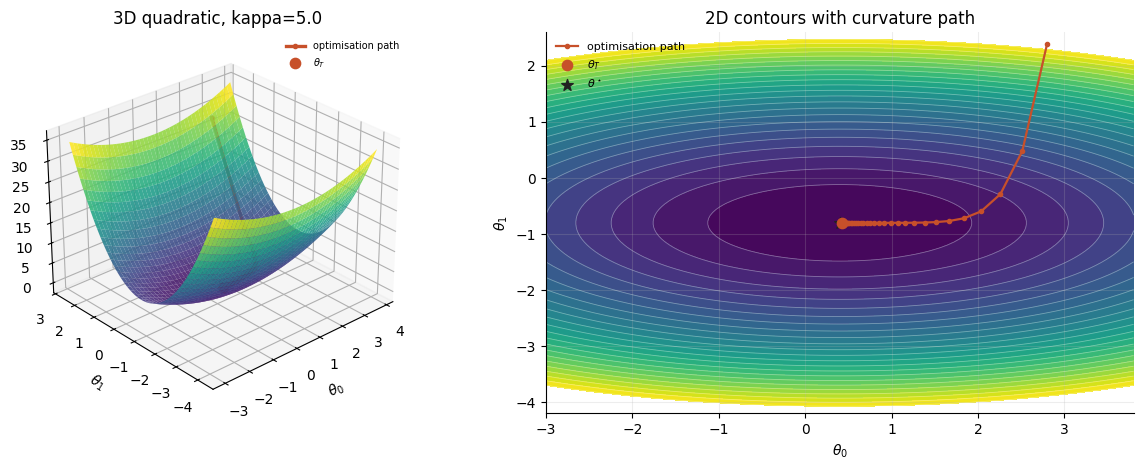

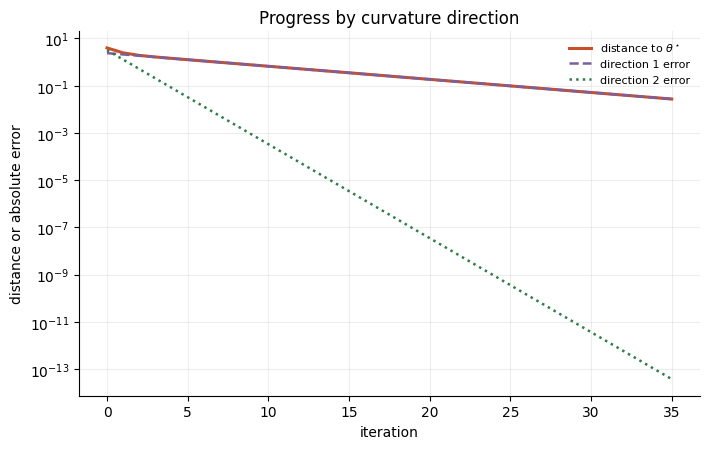

Condition number kappa = 5.00
Learning rate = 0.12
Final distance to theta_star = 0.027


In [7]:
lambda_min = 1.0
lambda_max = 5.0
learning_rate = 0.12
num_steps = 35
theta_init = np.array([2.8, 2.4])
theta_star = np.array([0.4, -0.8])

A = np.diag([lambda_min, lambda_max])
(theta_path, objective_values), objective_fn = quadratic_path(A, theta_init, theta_star, learning_rate, num_steps)
distances = np.linalg.norm(theta_path - theta_star, axis=1)
eigen_errors = theta_path - theta_star
kappa = lambda_max / lambda_min

theta0_range = (theta_star[0] - 3.4, theta_star[0] + 3.4)
theta1_range = (theta_star[1] - 3.4, theta_star[1] + 3.4)
T0, T1 = make_loss_mesh(theta0_range, theta1_range, points=130)
Z = evaluate_objective_mesh(T0, T1, objective_fn)
visible_path = finite_path_inside(theta_path, theta0_range, theta1_range)

fig = plt.figure(figsize=(12.4, 4.8))
ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
ax_contour = fig.add_subplot(1, 2, 2)
plot_3d_landscape(ax_surface, T0, T1, Z, f"3D quadratic, kappa={kappa:.1f}", path=visible_path, objective_fn=objective_fn, selected=theta_path[-1])
levels = np.linspace(float(np.min(Z)), float(np.quantile(Z, 0.92)), 24)
plot_2d_landscape(ax_contour, T0, T1, Z, "2D contours with curvature path", levels=levels, path=visible_path, selected=theta_path[-1])
ax_contour.scatter(theta_star[0], theta_star[1], color=COLORS["truth"], s=75, marker="*", label=r"$\theta^\star$")
ax_contour.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(distances, color=COLORS["selected"], lw=2.2, label=r"distance to $\theta^\star$")
ax.plot(np.abs(eigen_errors[:, 0]), color=COLORS["alt"], lw=1.8, ls="--", label="direction 1 error")
ax.plot(np.abs(eigen_errors[:, 1]), color=COLORS["regularised"], lw=1.8, ls=":", label="direction 2 error")
ax.set_title("Progress by curvature direction")
ax.set_xlabel("iteration")
ax.set_ylabel("distance or absolute error")
ax.set_yscale("log")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Condition number kappa = {kappa:.2f}")
print(f"Learning rate = {learning_rate}")
print(f"Final distance to theta_star = {distances[-1]:.3f}")


### Plot interpretation

In a well-conditioned landscape, progress can occur at a compatible rate in both directions. In an ill-conditioned landscape, one direction may move quickly while another remains under-trained or unstable.

### Mathematical unpacking

For a quadratic objective:

$$
J(\theta)
=
\frac{1}{2}(\theta-\theta^{\star})^{\top}A(\theta-\theta^{\star}),
$$

with symmetric positive definite $A$,

$$
\nabla J(\theta)=A(\theta-\theta^{\star}).
$$

Gradient descent updates errors as:

$$
\theta_{t+1}-\theta^{\star}
=
(I-\eta A)(\theta_t-\theta^{\star}).
$$

Convergence requires:

$$
0<\eta<\frac{2}{\lambda_{\max}(A)}.
$$

The condition number is:

$$
\kappa(A)=\frac{\lambda_{\max}(A)}{\lambda_{\min}(A)}.
$$

Large $\kappa(A)$ means the landscape is stretched.

### Researcher takeaway

Conditioning affects which solution is reached in finite training.

The practical question is:

$$
\text{Did the optimiser have enough time and suitable geometry to move in the directions that matter?}
$$


## 7. What Changes When Updates Are Stochastic?

### Motivation

Minibatches are often introduced as a computational shortcut. They also change the realised training path.

This section asks:

$$
\text{How does stochasticity shape the selected solution?}
$$

### Exploration

Train the same linear model using full-batch gradient descent and minibatch stochastic gradient descent. Keep the full-data objective as the reference surface.


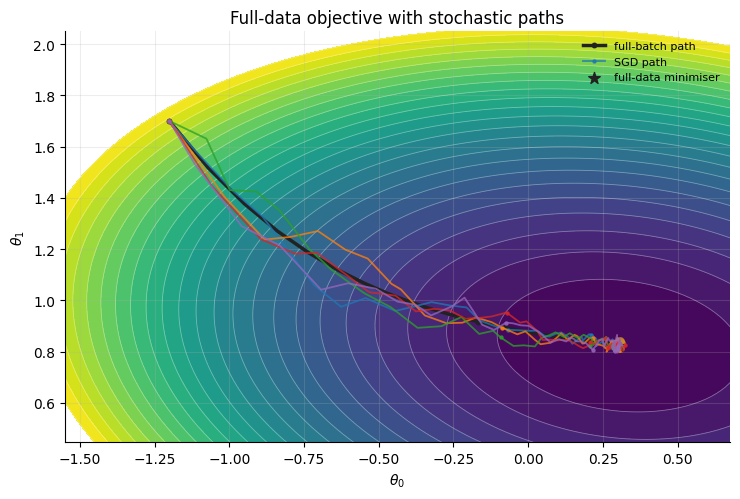

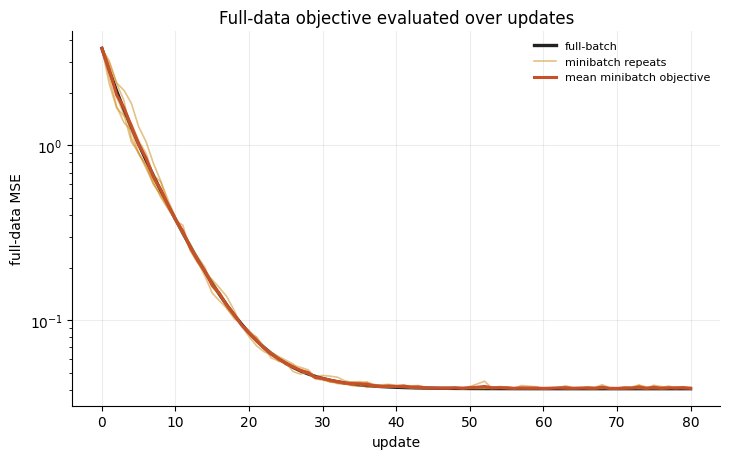

| Repeat | Final theta | Final full-data objective |
|---|---|---|
| 0 | [0.307, 0.813] | 0.04088 |
| 1 | [0.304, 0.822] | 0.04065 |
| 2 | [0.311, 0.831] | 0.04087 |
| 3 | [0.305, 0.840] | 0.04136 |
| 4 | [0.304, 0.829] | 0.04074 |

Batch size = 8
Number of repeats = 5
Mean final objective = 0.041
Std final objective = 0.000
Changed ingredient: O, via stochastic update path


In [8]:
seed = 41
batch_size = 8
learning_rate = 0.05
num_updates = 80
num_repeats = 5
shuffle_each_epoch = True

x, y = make_linear_dataset(n=80, seed=seed, outlier=False)
X = linear_design(x)
theta_init = np.array([-1.2, 1.7])
objective_fn = lambda theta: mse_objective(X, y, theta)
grad_fn = lambda theta: mse_gradient(X, y, theta)
full_path, full_values = gradient_descent(theta_init, grad_fn, objective_fn, learning_rate, num_updates)

sgd_paths = []
sgd_values = []
for repeat in range(num_repeats):
    path_repeat, values_repeat = minibatch_training_path(
        X,
        y,
        theta_init,
        learning_rate,
        num_updates,
        batch_size,
        seed=seed + 100 * repeat,
        shuffle_each_epoch=shuffle_each_epoch,
    )
    sgd_paths.append(path_repeat)
    sgd_values.append(values_repeat)
sgd_values = np.asarray(sgd_values)
final_objectives = sgd_values[:, -1]
mean_final_objective = float(np.mean(final_objectives))
std_final_objective = float(np.std(final_objectives))

theta_star = ridge_solution(X, y)
all_points = np.vstack([full_path, *sgd_paths, theta_star[None, :]])
theta0_range = (all_points[:, 0].min() - 0.35, all_points[:, 0].max() + 0.35)
theta1_range = (all_points[:, 1].min() - 0.35, all_points[:, 1].max() + 0.35)
T0, T1 = make_loss_mesh(theta0_range, theta1_range, points=135)
Z = evaluate_objective_mesh(T0, T1, objective_fn)

fig, ax = plt.subplots(figsize=(7.5, 5.1))
levels = np.linspace(float(np.min(Z)), float(np.quantile(Z, 0.92)), 24)
plot_2d_landscape(ax, T0, T1, Z, "Full-data objective with stochastic paths", levels=levels)
ax.plot(full_path[:, 0], full_path[:, 1], color=COLORS["truth"], lw=2.5, marker="o", markevery=12, ms=3.2, label="full-batch path")
for repeat, path_repeat in enumerate(sgd_paths):
    ax.plot(path_repeat[:, 0], path_repeat[:, 1], lw=1.3, alpha=0.78, marker="o", markevery=14, ms=2.2, label="SGD path" if repeat == 0 else None)
    ax.scatter(path_repeat[-1, 0], path_repeat[-1, 1], color=COLORS["sgd"], s=28, alpha=0.75)
ax.scatter(theta_star[0], theta_star[1], color=COLORS["truth"], s=75, marker="*", label="full-data minimiser")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.4, 4.7))
ax.plot(full_values, color=COLORS["truth"], lw=2.4, label="full-batch")
for repeat, values_repeat in enumerate(sgd_values):
    ax.plot(values_repeat, color=COLORS["sgd"], lw=1.2, alpha=0.55, label="minibatch repeats" if repeat == 0 else None)
ax.plot(np.mean(sgd_values, axis=0), color=COLORS["selected"], lw=2.2, label="mean minibatch objective")
ax.set_title("Full-data objective evaluated over updates")
ax.set_xlabel("update")
ax.set_ylabel("full-data MSE")
ax.set_yscale("log")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

rows = []
for repeat, path_repeat in enumerate(sgd_paths):
    rows.append((repeat, path_repeat[-1], sgd_values[repeat, -1]))
display_table(["Repeat", "Final theta", "Final full-data objective"], rows)

print(f"Batch size = {batch_size}")
print(f"Number of repeats = {num_repeats}")
print(f"Mean final objective = {mean_final_objective:.3f}")
print(f"Std final objective = {std_final_objective:.3f}")
print("Changed ingredient: O, via stochastic update path")


### Plot interpretation

Full-batch gradient descent follows a smooth path through the full-data objective. Minibatch paths are noisier. Different seeds can reach different finite-time parameter values.

### Mathematical unpacking

Full-batch gradient descent uses every observation:

$$
\nabla J(\theta)
=
\frac{1}{n}
\sum_{i=1}^{n}
\nabla_{\theta}\ell(h_{\theta}(x_i),y_i).
$$

Minibatch stochastic gradient descent uses a subset $B_t$:

$$
g_t
=
\frac{1}{|B_t|}
\sum_{i\in B_t}
\nabla_{\theta}\ell(h_{\theta}(x_i),y_i).
$$

The update is:

$$
\theta_{t+1}=\theta_t-\eta g_t.
$$

Under uniform sampling:

$$
\mathbb{E}[g_t\mid\theta_t]=\nabla J(\theta_t),
$$

but:

$$
\operatorname{Var}(g_t\mid\theta_t)>0.
$$

The gradient estimate may be unbiased while the realised final solution still depends on the stochastic path.

### Researcher takeaway

Stochasticity is part of $\mathcal{O}$. The selected model is an outcome of a random training process.

The practical question is:

$$
\text{How variable is the selected solution across seeds and batches?}
$$


## 8. What Preference Does Regularisation Add?

### Motivation

Regularisation is not just an anti-overfitting trick. It is an explicit preference among solutions.

This section asks:

$$
\text{Which compatible solution does the penalty prefer?}
$$

### Exploration

Use the same observed dataset and linear hypothesis space. Change only the ridge penalty $\lambda$.


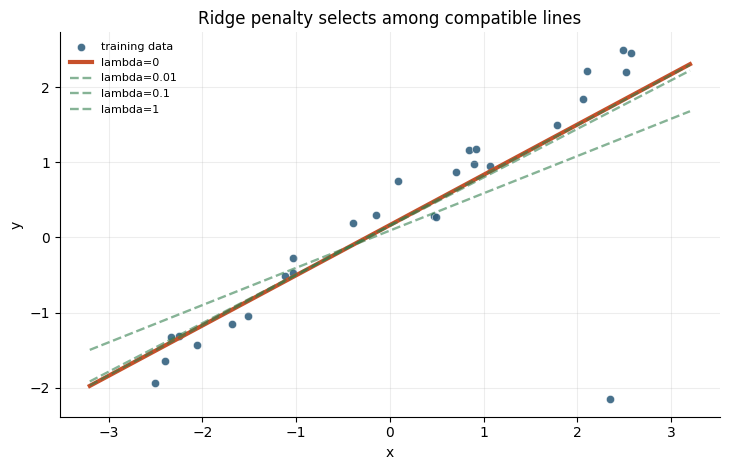

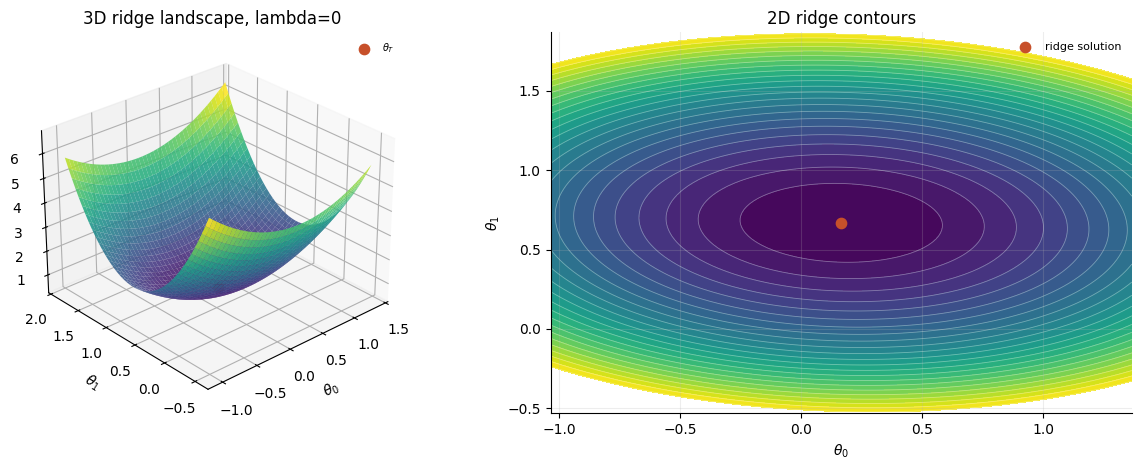

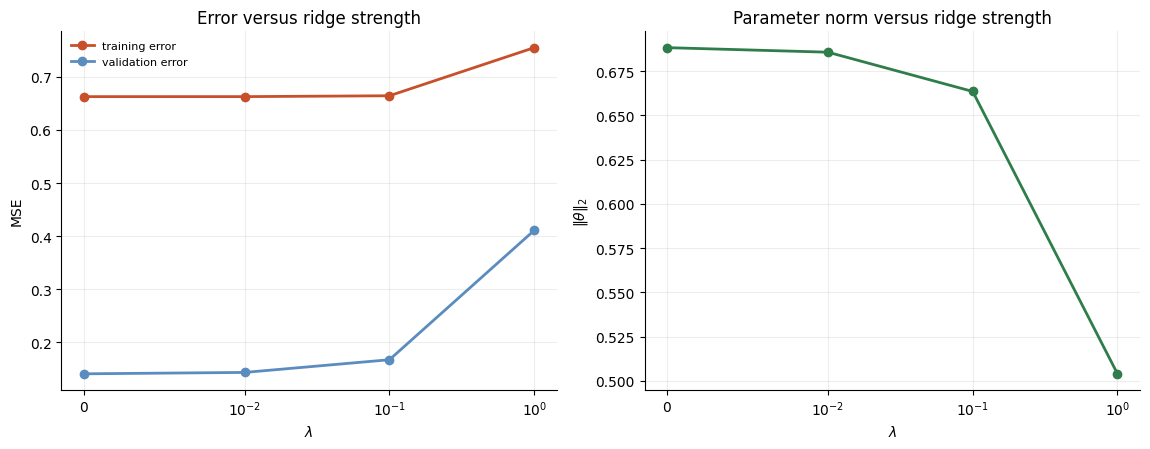

| lambda | theta | Training error | Validation error | Parameter norm | Preference |
|---|---|---|---|---|---|
| 0 | [0.165, 0.668] | 0.6628 | 0.1408 | 0.6883 | least constrained fit |
| 0.01 | [0.164, 0.666] | 0.6628 | 0.1435 | 0.6857 | smoother compatible fit |
| 0.1 | [0.153, 0.646] | 0.6644 | 0.1674 | 0.6635 | strong norm preference |
| 1 | [0.092, 0.496] | 0.755 | 0.411 | 0.504 | strong norm preference |

lambda = 0.0
Selected theta = [0.1654194  0.66807845]
Training error = 0.663
Validation error = 0.141
Parameter norm = 0.688


In [9]:
seed = 31
outlier = True
lambda_ridge = 0.0
validation_seed = 32
lambda_values = [0.0, 0.01, 0.1, 1.0]

x_train, y_train = make_linear_dataset(n=26, seed=seed, outlier=outlier)
rng_val = set_seed(validation_seed)
x_val = np.sort(rng_val.uniform(-2.7, 2.7, 80))
y_val = true_linear_function(x_val) + rng_val.normal(0.0, 0.18, len(x_val))
X_train = linear_design(x_train)
X_val = linear_design(x_val)
if lambda_ridge not in lambda_values:
    lambda_values = sorted([*lambda_values, lambda_ridge])

rows = []
thetas = {}
train_errors = []
val_errors = []
norms = []
for lam in lambda_values:
    theta_lam = ridge_solution(X_train, y_train, lam=lam)
    thetas[lam] = theta_lam
    train_error_lam = mse_objective(X_train, y_train, theta_lam, lam=0.0)
    val_error_lam = mse_objective(X_val, y_val, theta_lam, lam=0.0)
    theta_norm_lam = float(np.linalg.norm(theta_lam))
    train_errors.append(train_error_lam)
    val_errors.append(val_error_lam)
    norms.append(theta_norm_lam)
    rows.append((lam, theta_lam, train_error_lam, val_error_lam, theta_norm_lam, describe_lambda(lam)))

theta_hat = thetas[lambda_ridge]
train_error = mse_objective(X_train, y_train, theta_hat, lam=0.0)
val_error = mse_objective(X_val, y_val, theta_hat, lam=0.0)
theta_norm = float(np.linalg.norm(theta_hat))

fig, ax = plt.subplots(figsize=(7.4, 4.8))
plot_observed(ax, x_train, y_train, label="training data")
for lam in lambda_values:
    active = lam == lambda_ridge
    color = COLORS["selected"] if active else COLORS["regularised"]
    lw = 3.0 if active else 1.7
    alpha = 1.0 if active else 0.58
    plot_linear_fit(ax, thetas[lam], label=f"lambda={lam:g}", color=color, lw=lw, ls="-" if active else "--")
    ax.lines[-1].set_alpha(alpha)
ax.set_title("Ridge penalty selects among compatible lines")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

objective_fn = lambda theta: mse_objective(X_train, y_train, theta, lam=lambda_ridge)
theta0_range = (theta_hat[0] - 1.2, theta_hat[0] + 1.2)
theta1_range = (theta_hat[1] - 1.2, theta_hat[1] + 1.2)
T0, T1 = make_loss_mesh(theta0_range, theta1_range, points=130)
Z = evaluate_objective_mesh(T0, T1, objective_fn)
fig = plt.figure(figsize=(12.4, 4.8))
ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
ax_contour = fig.add_subplot(1, 2, 2)
plot_3d_landscape(ax_surface, T0, T1, Z, f"3D ridge landscape, lambda={lambda_ridge:g}", objective_fn=objective_fn, selected=theta_hat)
levels = np.linspace(float(np.min(Z)), float(np.quantile(Z, 0.92)), 24)
plot_2d_landscape(ax_contour, T0, T1, Z, "2D ridge contours", levels=levels, selected=theta_hat, selected_label="ridge solution")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
axes[0].plot(lambda_values, train_errors, marker="o", color=COLORS["selected"], lw=2.0, label="training error")
axes[0].plot(lambda_values, val_errors, marker="o", color=COLORS["validation"], lw=2.0, label="validation error")
axes[0].set_xscale("symlog", linthresh=0.01)
axes[0].set_title("Error versus ridge strength")
axes[0].set_xlabel(r"$\lambda$")
axes[0].set_ylabel("MSE")
axes[0].legend(fontsize=8)
axes[1].plot(lambda_values, norms, marker="o", color=COLORS["regularised"], lw=2.0)
axes[1].set_xscale("symlog", linthresh=0.01)
axes[1].set_title("Parameter norm versus ridge strength")
axes[1].set_xlabel(r"$\lambda$")
axes[1].set_ylabel(r"$\|\theta\|_2$")
plt.tight_layout()
plt.show()

display_table(["lambda", "theta", "Training error", "Validation error", "Parameter norm", "Preference"], rows)

print(f"lambda = {lambda_ridge}")
print(f"Selected theta = {theta_hat}")
print(f"Training error = {train_error:.3f}")
print(f"Validation error = {val_error:.3f}")
print(f"Parameter norm = {theta_norm:.3f}")


### Plot interpretation

Increasing $\lambda$ changes the objective. The selected line may fit the observed points less aggressively, especially if an outlier would require a large coefficient.

Training error, validation error, and coefficient norm answer different questions.

### Mathematical unpacking

A regularised objective is:

$$
J_{\lambda}(\theta)
=
\widehat{R}_{\mathcal{D}}(h_{\theta})
+
\lambda\Omega(\theta).
$$

For ridge regression:

$$
\Omega(\theta)=\|\theta\|_2^2.
$$

For squared-loss linear regression:

$$
J_{\lambda}(\theta)
=
\frac{1}{n}\|X\theta-y\|_2^2
+
\lambda\|\theta\|_2^2.
$$

The ridge solution is:

$$
\widehat{\theta}_{\lambda}
=
(X^{\top}X+n\lambda I)^{-1}X^{\top}y.
$$

### Researcher takeaway

Regularisation declares a preference. It says what kind of solution should be selected when empirical fit alone is not enough.

The practical question is:

$$
\text{What preference did the penalty encode, and is that preference justified by the research claim?}
$$


## 9. Where Can Initialisation Matter?

### Motivation

In non-convex optimisation, the starting point can affect which basin the optimiser reaches. A single seed may not represent the training procedure.

This section asks:

$$
\text{How much does the selected solution depend on the start?}
$$

### Exploration

Use a toy two-parameter non-convex objective so the landscape can be drawn directly. Hold objective, learning rate, and update rule fixed. Change only the initial point or random seed.


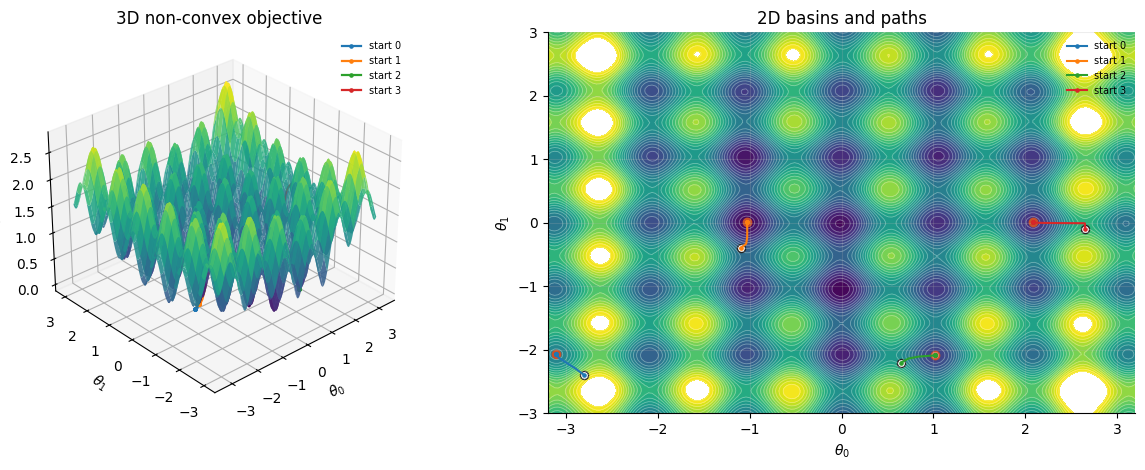

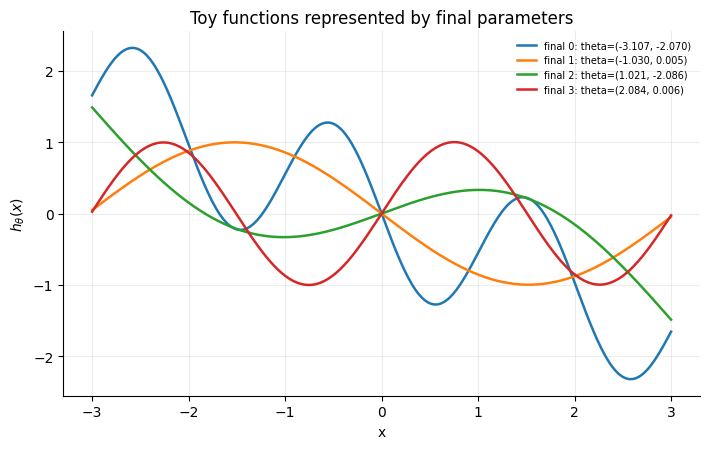

| Start | theta_0 | theta_T | Final objective |
|---|---|---|---|
| 0 | [-2.800, -2.400] | [-3.107, -2.070] | 0.9075 |
| 1 | [-1.100, -0.400] | [-1.030, 0.005] | -0.04507 |
| 2 | [0.650, -2.200] | [1.021, -2.086] | 0.3445 |
| 3 | [2.650, -0.100] | [2.084, 0.006] | 0.2199 |

Number of starts = 4
Final objective values:
| Start | theta_0 | theta_T | Final objective |
|---|---|---|---|
| 0 | [-2.800, -2.400] | [-3.107, -2.070] | 0.9075 |
| 1 | [-1.100, -0.400] | [-1.030, 0.005] | -0.04507 |
| 2 | [0.650, -2.200] | [1.021, -2.086] | 0.3445 |
| 3 | [2.650, -0.100] | [2.084, 0.006] | 0.2199 |
Changed ingredient: O, via initialisation


In [10]:
seed = 7
learning_rate = 0.045
num_steps = 120
start_points = [
    (-2.8, -2.4),
    (-1.1, -0.4),
    (0.65, -2.2),
    (2.65, -0.1),
]

starts = np.asarray(start_points, dtype=float)
objective_fn = nonconvex_objective
grad_fn = nonconvex_gradient
paths = []
values = []
for start in starts:
    path_start, values_start = gradient_descent(start, grad_fn, objective_fn, learning_rate, num_steps)
    paths.append(path_start)
    values.append(values_start)

T0, T1 = make_loss_mesh((-3.2, 3.2), (-3.0, 3.0), points=170)
Z = evaluate_objective_mesh(T0, T1, objective_fn)
levels = np.linspace(float(np.min(Z)), float(np.quantile(Z, 0.96)), 28)

fig = plt.figure(figsize=(12.4, 4.8))
ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
ax_contour = fig.add_subplot(1, 2, 2)
ax_surface.plot_surface(T0, T1, Z, cmap=VIRIDIS_CMAP, alpha=0.88, linewidth=0, antialiased=True)
for i, path_start in enumerate(paths):
    z_path = np.array([objective_fn(theta) for theta in path_start])
    ax_surface.plot(path_start[:, 0], path_start[:, 1], z_path, lw=1.6, marker="o", markevery=18, ms=2.3, label=f"start {i}")
ax_surface.set_title("3D non-convex objective")
ax_surface.set_xlabel(r"$\theta_0$")
ax_surface.set_ylabel(r"$\theta_1$")
ax_surface.set_zlabel(r"$J(\theta)$")
ax_surface.view_init(elev=30, azim=-132)
ax_surface.legend(fontsize=7)
plot_2d_landscape(ax_contour, T0, T1, Z, "2D basins and paths", levels=levels)
for i, path_start in enumerate(paths):
    ax_contour.plot(path_start[:, 0], path_start[:, 1], lw=1.5, marker="o", markevery=18, ms=2.3, label=f"start {i}")
    ax_contour.scatter(path_start[0, 0], path_start[0, 1], color="white", edgecolor=COLORS["truth"], s=34)
    ax_contour.scatter(path_start[-1, 0], path_start[-1, 1], color=COLORS["selected"], s=36)
ax_contour.legend(fontsize=7)
plt.tight_layout()
plt.show()

x_grid = np.linspace(-3.0, 3.0, 300)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for i, path_start in enumerate(paths):
    theta_final = path_start[-1]
    y_function = np.sin(theta_final[0] * x_grid) + 0.25 * theta_final[1] * x_grid
    ax.plot(x_grid, y_function, lw=1.8, label=f"final {i}: theta={format_theta(theta_final)}")
ax.set_title("Toy functions represented by final parameters")
ax.set_xlabel("x")
ax.set_ylabel(r"$h_\theta(x)$")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

rows = []
for i, (start, path_start, values_start) in enumerate(zip(starts, paths, values)):
    rows.append((i, start, path_start[-1], values_start[-1]))
final_table = markdown_table(["Start", "theta_0", "theta_T", "Final objective"], rows)
display_markdown(final_table)

print(f"Number of starts = {len(start_points)}")
print("Final objective values:")
print(final_table)
print("Changed ingredient: O, via initialisation")


### Plot interpretation

Different starts can fall into different basins. Some final parameters may have similar objective values but imply different behaviour elsewhere.

### Mathematical unpacking

A non-convex training objective may have many local minima, saddle points, flat regions, and symmetries:

$$
J(\theta)
=
\frac{1}{n}
\sum_{i=1}^{n}
\ell(h_{\theta}(x_i),y_i).
$$

Training starts from:

$$
\theta_0\sim P_{\mathrm{init}},
$$

then follows optimiser dynamics. Different starts can produce different final parameters:

$$
\theta_T^{(1)}\neq\theta_T^{(2)}.
$$

The corresponding functions may agree on training data but differ elsewhere:

$$
h_{\theta_T^{(1)}}(x_i)\approx h_{\theta_T^{(2)}}(x_i)
\quad
\text{for observed }x_i,
$$

while:

$$
h_{\theta_T^{(1)}}(x)\neq h_{\theta_T^{(2)}}(x)
\quad
\text{outside observed support.}
$$

### Researcher takeaway

Initialisation is part of $\mathcal{O}$. Seed sensitivity is evidence about the training procedure.

The practical question is:

$$
\text{Does the reported solution persist across reasonable initialisations?}
$$


## 10. Which Iterate Is Reported?

### Motivation

Training normally returns a finite-time model, not an exact global minimiser. The stopping rule decides which point on the path becomes the reported solution.

This section asks:

$$
\text{Which iterate becomes }s?
$$

### Exploration

Follow one trajectory and compare early, validation-selected, and late iterates.


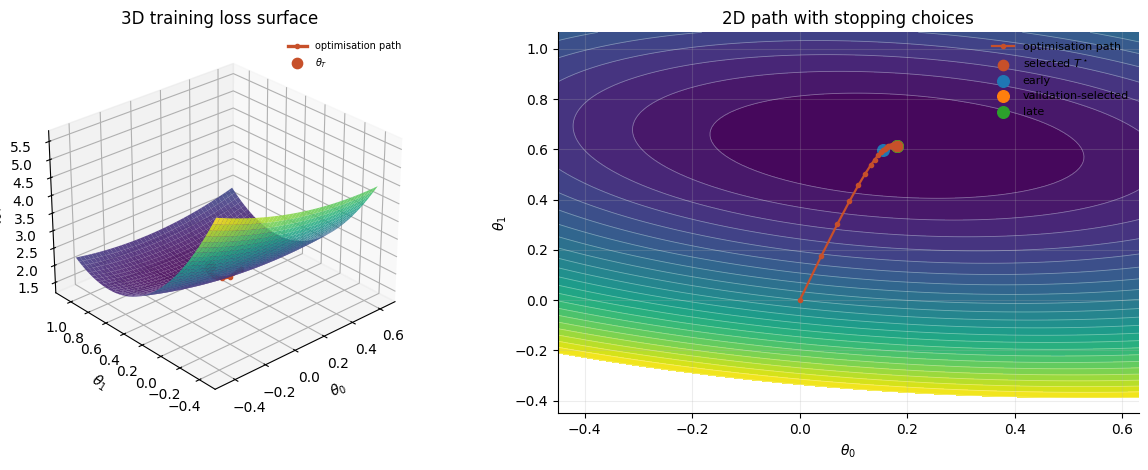

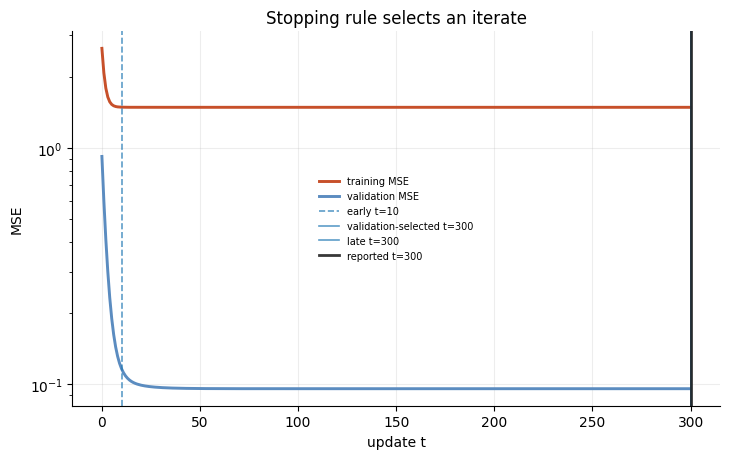

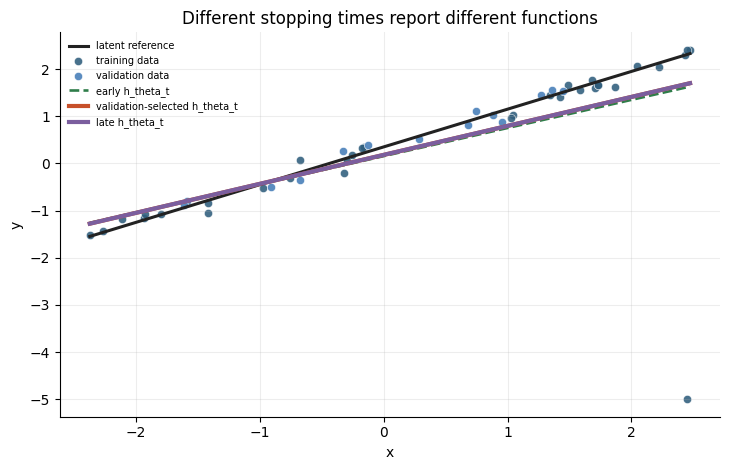

| Stopping rule | t | Training MSE | Validation MSE | theta_t |
|---|---|---|---|---|
| early | 10 | 1.491 | 0.1166 | [0.154, 0.596] |
| validation-selected | 300 | 1.489 | 0.09589 | [0.181, 0.614] |
| late | 300 | 1.489 | 0.09589 | [0.181, 0.614] |
| reported | 300 | 1.489 | 0.09589 | [0.181, 0.614] |

Selected stopping rule = validation
T_star = 300
Training error at T_star = 1.489
Validation error at T_star = 0.096
Changed ingredient: O, via stopping rule


In [11]:
seed = 42
learning_rate = 0.05
max_steps = 300
validation_fraction = 0.3
selected_step = "validation"  # "early", "validation", "late", or integer

rng = set_seed(seed)
x_all = np.sort(rng.uniform(-2.6, 2.6, 46))
y_all = true_linear_function(x_all) + rng.normal(0.0, 0.18, len(x_all))
order = rng.permutation(len(x_all))
n_val = int(round(validation_fraction * len(x_all)))
val_idx = order[:n_val]
train_idx = order[n_val:]
x_train = x_all[train_idx]
y_train = y_all[train_idx]
x_val = x_all[val_idx]
y_val = y_all[val_idx]
x_train = np.concatenate([x_train, [2.45]])
y_train = np.concatenate([y_train, [-5.0]])
X_train = linear_design(x_train)
X_val = linear_design(x_val)

objective_train = lambda theta: mse_objective(X_train, y_train, theta)
grad_train = lambda theta: mse_gradient(X_train, y_train, theta)
theta_path, train_error = gradient_descent(np.array([0.0, 0.0]), grad_train, objective_train, learning_rate, max_steps)
val_error = np.array([mse_objective(X_val, y_val, theta) for theta in theta_path])
validation_t = int(np.argmin(val_error))
early_t = min(10, max_steps)
late_t = max_steps
if isinstance(selected_step, str):
    selected_key = selected_step.lower()
    if selected_key == "early":
        T_star = early_t
    elif selected_key == "validation":
        T_star = validation_t
    elif selected_key == "late":
        T_star = late_t
    else:
        raise ValueError("selected_step must be 'early', 'validation', 'late', or an integer")
else:
    T_star = int(np.clip(selected_step, 0, max_steps))

checkpoints = {
    "early": early_t,
    "validation-selected": validation_t,
    "late": late_t,
}

theta_hat = ridge_solution(X_train, y_train)
theta0_range = (min(theta_path[:, 0].min(), theta_hat[0]) - 0.45, max(theta_path[:, 0].max(), theta_hat[0]) + 0.45)
theta1_range = (min(theta_path[:, 1].min(), theta_hat[1]) - 0.45, max(theta_path[:, 1].max(), theta_hat[1]) + 0.45)
T0, T1 = make_loss_mesh(theta0_range, theta1_range, points=130)
Z = evaluate_objective_mesh(T0, T1, objective_train)

fig = plt.figure(figsize=(12.4, 4.8))
ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
ax_contour = fig.add_subplot(1, 2, 2)
plot_3d_landscape(ax_surface, T0, T1, Z, "3D training loss surface", path=theta_path, objective_fn=objective_train, selected=theta_path[T_star])
levels = np.linspace(float(np.min(Z)), float(np.quantile(Z, 0.92)), 24)
plot_2d_landscape(ax_contour, T0, T1, Z, "2D path with stopping choices", levels=levels, path=theta_path, selected=theta_path[T_star], selected_label=r"selected $T^\star$")
for label, t in checkpoints.items():
    ax_contour.scatter(theta_path[t, 0], theta_path[t, 1], s=70, label=label)
ax_contour.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.4, 4.7))
ax.plot(train_error, color=COLORS["selected"], lw=2.1, label="training MSE")
ax.plot(val_error, color=COLORS["validation"], lw=2.1, label="validation MSE")
for label, t in checkpoints.items():
    ax.axvline(t, ls="--" if t != T_star else "-", lw=1.2, alpha=0.72, label=f"{label} t={t}")
ax.axvline(T_star, color=COLORS["truth"], lw=2.0, alpha=0.9, label=f"reported t={T_star}")
ax.set_title("Stopping rule selects an iterate")
ax.set_xlabel("update t")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

x_grid = np.linspace(min(x_all.min(), x_train.min()), max(x_all.max(), x_train.max()), 300)
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(x_grid, true_linear_function(x_grid), color=COLORS["truth"], lw=2.2, label="latent reference")
plot_observed(ax, x_train, y_train, label="training data")
ax.scatter(x_val, y_val, s=35, color=COLORS["validation"], edgecolor="white", linewidth=0.4, label="validation data")
for label, t in checkpoints.items():
    color = COLORS["regularised"] if label == "early" else COLORS["selected"] if label == "validation-selected" else COLORS["alt"]
    lw = 3.0 if t == T_star else 1.9
    plot_linear_fit(ax, theta_path[t], x_grid=x_grid, label=f"{label} h_theta_t", color=color, lw=lw, ls="-" if t == T_star else "--")
if T_star not in checkpoints.values():
    plot_linear_fit(ax, theta_path[T_star], x_grid=x_grid, label="reported iterate", color=COLORS["truth"], lw=2.5)
ax.set_title("Different stopping times report different functions")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

rows = []
for label, t in checkpoints.items():
    rows.append((label, t, train_error[t], val_error[t], theta_path[t]))
rows.append(("reported", T_star, train_error[T_star], val_error[T_star], theta_path[T_star]))
display_table(["Stopping rule", "t", "Training MSE", "Validation MSE", "theta_t"], rows)

print(f"Selected stopping rule = {selected_step}")
print(f"T_star = {T_star}")
print(f"Training error at T_star = {train_error[T_star]:.3f}")
print(f"Validation error at T_star = {val_error[T_star]:.3f}")
print("Changed ingredient: O, via stopping rule")


### Plot interpretation

Training loss may keep falling while validation loss stops improving. Different stopping times select different functions from the same trajectory.

### Mathematical unpacking

Training produces:

$$
\theta_0,\theta_1,\ldots,\theta_T.
$$

A finite-time selected solution is:

$$
s=h_{\theta_T}.
$$

A validation-based stopping rule is:

$$
T^{\star}
=
\arg\min_{t\in\{0,\ldots,T_{\max}\}}
\widehat{R}_{\mathrm{val}}(h_{\theta_t}).
$$

Then the reported solution is:

$$
s=h_{\theta_{T^{\star}}}.
$$

### Researcher takeaway

Stopping is a selection rule. It must be reported as part of the evidence behind the trained model.

The practical question is:

$$
\text{Why was this iterate selected rather than an earlier or later one?}
$$


## 11. Final Optimisation Audit

### Motivation

The final audit turns the notebook into a checklist for interpreting trained models.

This section asks:

$$
\text{Which part of }\mathcal{H}+\mathcal{D}+\mathcal{O}\text{ explains the observed behaviour?}
$$


In [12]:
scenario = "high_train_error"

# Options:
# scenario = "high_train_error"
# scenario = "good_train_bad_shift"
# scenario = "seed_sensitive"
# scenario = "regularisation_sensitive"
# scenario = "early_stopping_sensitive"
# scenario = "loss_sensitive"

audit_rows = [
    ("High training error", r"$\mathcal{H}$ or $\mathcal{O}$", "capacity, optimisation path"),
    (r"Same $\mathcal{D}$ and $\mathcal{H}$, different solutions", r"$\mathcal{O}$", "loss, seed, batch size, stopping"),
    ("Good random-test error, bad shifted-context error", r"$\mathcal{D}$ or deployment mismatch", "validation design"),
    (r"Strong sensitivity to $\lambda$", r"$\mathcal{O}$", "regularisation preference"),
    ("Training loss keeps falling, validation worsens", r"$\mathcal{O}$", "stopping rule"),
]

scenario_focus = {
    "high_train_error": ("High training error", r"$\mathcal{H}$ or $\mathcal{O}$", "capacity, optimisation path"),
    "good_train_bad_shift": ("Good random-test error, bad shifted-context error", r"$\mathcal{D}$ or deployment mismatch", "validation design"),
    "seed_sensitive": (r"Same $\mathcal{D}$ and $\mathcal{H}$, different solutions", r"$\mathcal{O}$", "initialisation, batch order, stochastic path"),
    "regularisation_sensitive": (r"Strong sensitivity to $\lambda$", r"$\mathcal{O}$", "regularisation preference"),
    "early_stopping_sensitive": ("Training loss keeps falling, validation worsens", r"$\mathcal{O}$", "stopping rule"),
    "loss_sensitive": ("Same data, different fit after changing loss", r"$\mathcal{O}$", "loss and estimand"),
}

focus = scenario_focus.get(scenario, scenario_focus["high_train_error"])
display_table(["Observation", "Likely source", "What to check"], audit_rows)
display_markdown(
    "\n".join(
        [
            f"**Selected scenario:** `{scenario}`",
            "",
            markdown_table(["Observation", "Likely source", "What to check"], [focus]),
        ]
    )
)


| Observation | Likely source | What to check |
|---|---|---|
| High training error | $\mathcal{H}$ or $\mathcal{O}$ | capacity, optimisation path |
| Same $\mathcal{D}$ and $\mathcal{H}$, different solutions | $\mathcal{O}$ | loss, seed, batch size, stopping |
| Good random-test error, bad shifted-context error | $\mathcal{D}$ or deployment mismatch | validation design |
| Strong sensitivity to $\lambda$ | $\mathcal{O}$ | regularisation preference |
| Training loss keeps falling, validation worsens | $\mathcal{O}$ | stopping rule |

**Selected scenario:** `high_train_error`

| Observation | Likely source | What to check |
|---|---|---|
| High training error | $\mathcal{H}$ or $\mathcal{O}$ | capacity, optimisation path |

### Mathematical unpacking

Optimisation maps data and candidates to a selected solution:

$$
\mathcal{O}:(\mathcal{H},\mathcal{D})\mapsto s.
$$

In practice, $\mathcal{O}$ includes:

$$
\text{loss}
+
\text{regularisation}
+
\text{initialisation}
+
\text{update rule}
+
\text{stochasticity}
+
\text{stopping rule}.
$$

Two learners can share the same data and hypothesis space but select different solutions:

$$
(\mathcal{H},\mathcal{D},\mathcal{O}_1)\rightarrow s_1,
\qquad
(\mathcal{H},\mathcal{D},\mathcal{O}_2)\rightarrow s_2.
$$

### Researcher takeaway

The core lesson is not that one optimiser is always better. The lesson is that training is a selection procedure.

The final audit is:

$$
\text{What objective was minimised?}
$$

$$
\text{What geometry was searched?}
$$

$$
\text{What path was followed?}
$$

$$
\text{Which rule selected the reported iterate?}
$$

$$
\text{Does that selected solution support the research claim?}
$$
